<a href="https://colab.research.google.com/github/PranshuGhori/flightdata-eda/blob/main/Flight_Delay_EDA_2019_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **Flight Delay and Cancellation Dataset (2019-2023) - Exploratory Data Analysis**

https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023

##Download the Dataset

In [25]:
import kagglehub
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt

# Download dataset
path = kagglehub.dataset_download(
    "patrickzel/flight-delay-and-cancellation-dataset-2019-2023"
)

print("Dataset path:", path)
print("Files:", os.listdir(path))

# Load first CSV found
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
df = pd.read_csv(os.path.join(path, csv_files[0]))

df.head()


Using Colab cache for faster access to the 'flight-delay-and-cancellation-dataset-2019-2023' dataset.
Dataset path: /kaggle/input/flight-delay-and-cancellation-dataset-2019-2023
Files: ['flights_sample_3m.csv', 'dictionary.html']


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


Using Colab cache for faster access to the 'flight-delay-and-cancellation-dataset-2019-2023' dataset.
Dataset path: /kaggle/input/flight-delay-and-cancellation-dataset-2019-2023
Files: ['flights_sample_3m.csv', 'dictionary.html']


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN




---



---



##Data Preparation

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [27]:
df.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,...,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,...,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,...,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,...,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,...,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,...,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,...,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000


,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,...,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,...,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,...,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,...,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,...,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,...,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,...,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000




---



---



##**Exploratory Analysis and Visualization**




---



**1. How many total flights are in the dataset, and how many per year/month?**

The dataset contains 3 million flight observations, each representing one scheduled flight, including information on flight times, delays, cancellations, and causes.

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA



---



**2. Which airlines operate the most flights overall?**

The dataset is dominated by major carriers, with Southwest Airlines (576K flights) representing nearly 19% of all flights, followed by Delta and American Airlines.
Regional carriers such as SkyWest, Republic, and Envoy also contribute significantly, reflecting their role as connector or feeder airlines in the U.S. network.


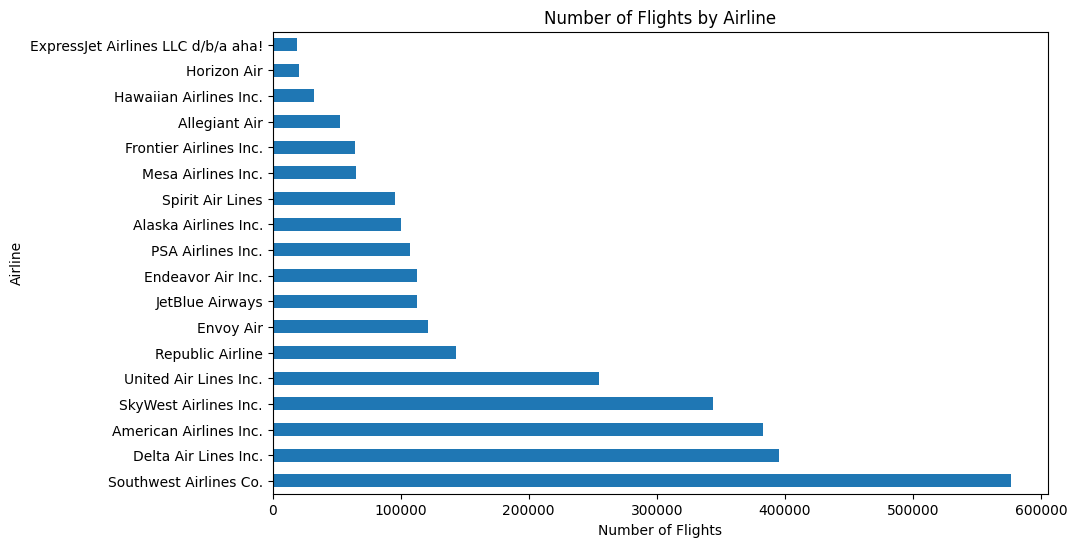

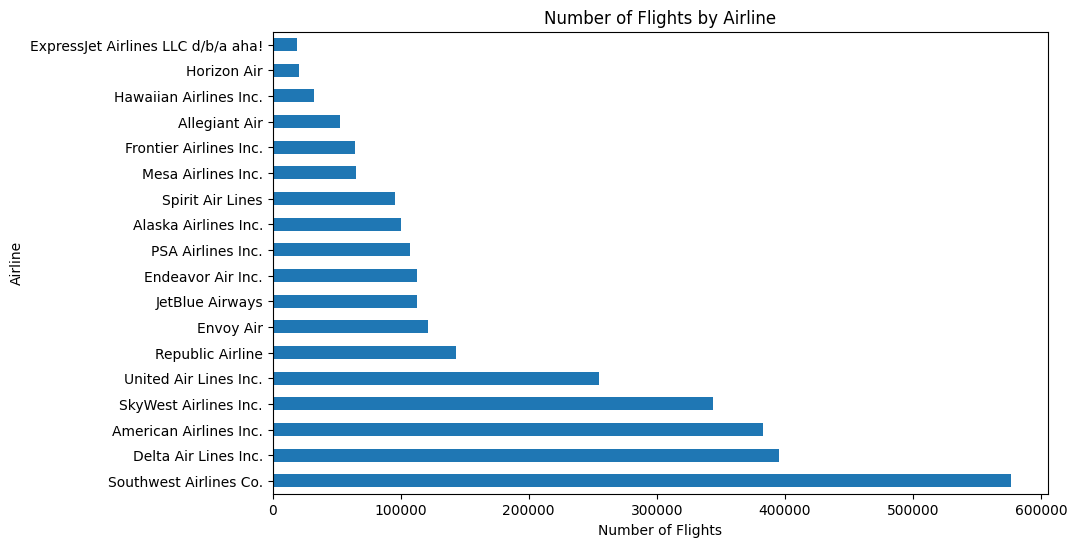

In [29]:
airlines = df['AIRLINE'].value_counts().plot(kind='barh', figsize=(10, 6))
airlines.set_title('Number of Flights by Airline')
airlines.set_xlabel('Number of Flights')
airlines.set_ylabel('Airline')
plt.show()

<Axes: xlabel='AIRLINE'>

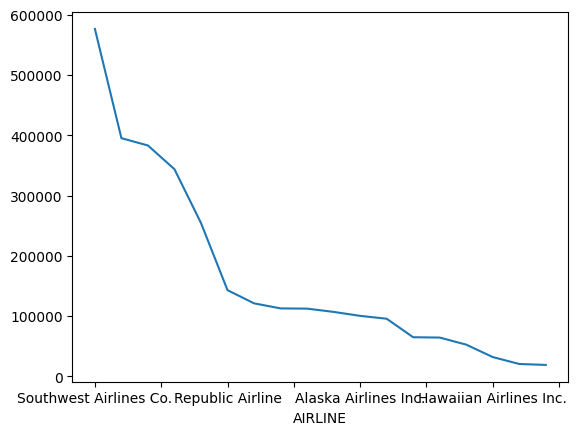

<Axes: xlabel='AIRLINE'>

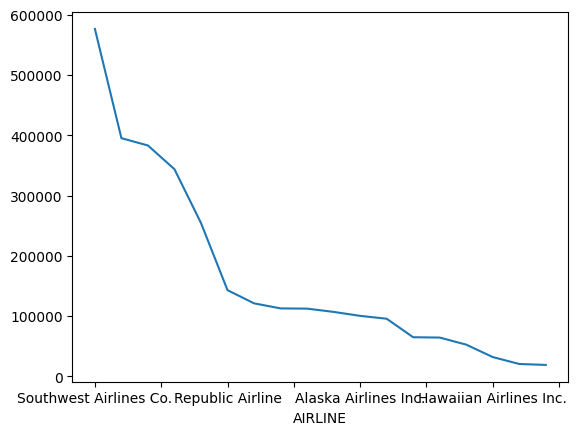

In [30]:
df['AIRLINE'].value_counts().plot()



---



**3. Which airports have the highest number of departures and arrivals?**

The busiest airports in the U.S. dataset are Atlanta (ATL), Dallas/Fort Worth (DFW), and Chicago O’Hare (ORD).
These major hubs dominate both departure and arrival volumes, reflecting their central role in national air traffic.
Western hubs like LAX, PHX, and SEA also appear in the top 10, showing balanced nationwide activity.

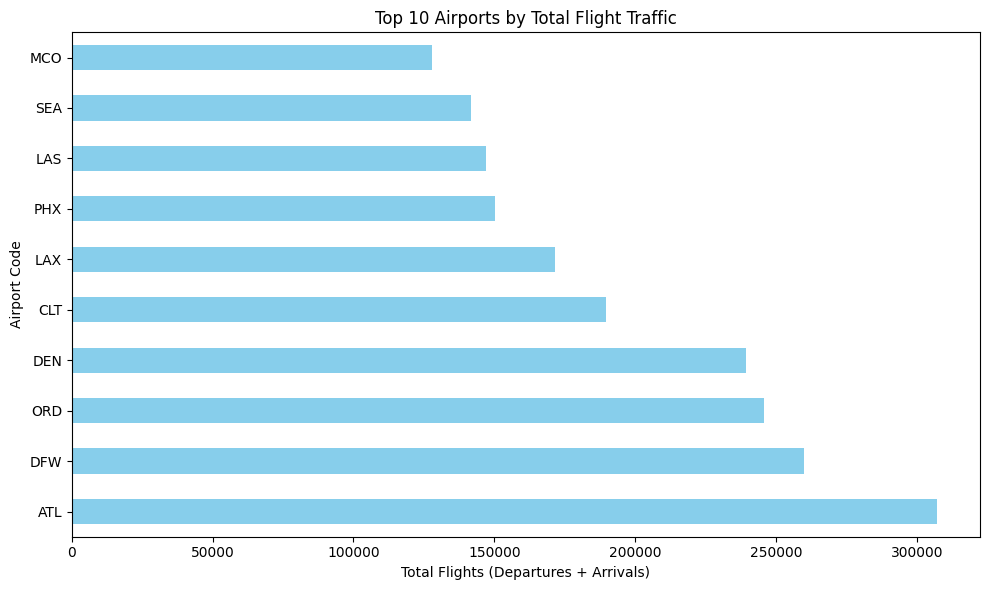

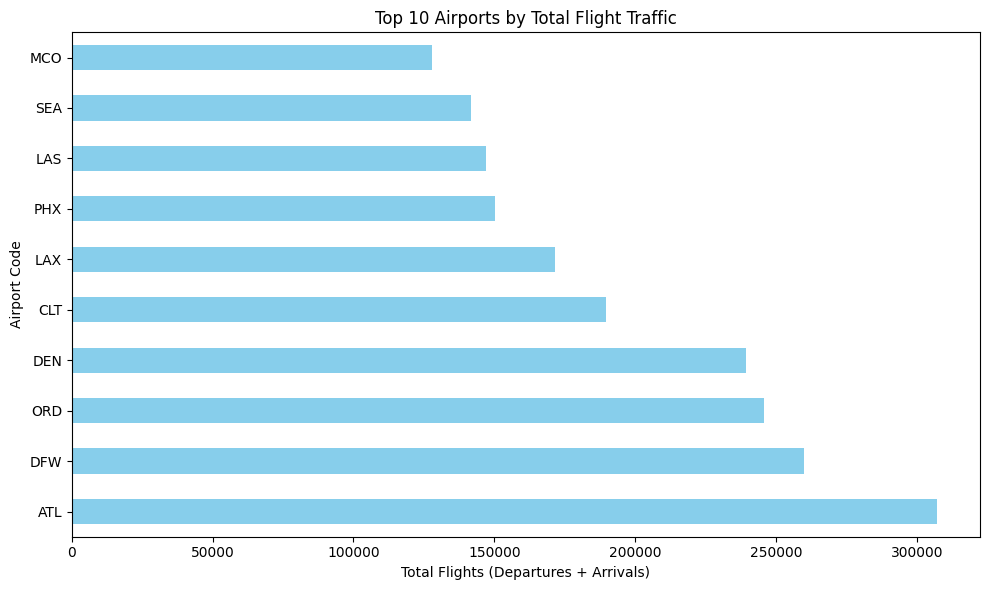

In [31]:
import matplotlib.pyplot as plt
departures = df['ORIGIN'].value_counts()
arrivals   = df['DEST'].value_counts()

airport_traffic = (departures + arrivals).sort_values(ascending=False)
airport_traffic = airport_traffic.fillna(0).astype(int)
ax = airport_traffic.head(10).plot(kind='barh', figsize=(10,6), color='skyblue')
plt.title('Top 10 Airports by Total Flight Traffic')
plt.xlabel('Total Flights (Departures + Arrivals)')
plt.ylabel('Airport Code')
plt.tight_layout()
plt.show()





---



**4. What percentage of flights were cancelled or diverted?**

Out of 3 million total flights, approximately 2.6% were cancelled and 0.3% were diverted.
This indicates that over 97% of flights operated successfully, showing overall strong operational reliability across U.S. airlines.

In [32]:
(df['CANCELLED'].value_counts()/len(df))*100

,count
CANCELLED,
0.0,97.362
1.0,2.638


,count
CANCELLED,
0.0,97.362
1.0,2.638


In [33]:
(df['DIVERTED'].value_counts() / len(df)) * 100


,count
DIVERTED,
0.0,99.7648
1.0,0.2352


,count
DIVERTED,
0.0,99.7648
1.0,0.2352




---



**5. What is the average departure delay and arrival delay across all flights?**

On average, flights depart about 10 minutes late but arrive only 4 minutes late.
This suggests that most flights make up some lost time while airborne, a common pattern in U.S. commercial aviation where airlines build small buffer times into their schedules.


In [34]:
df[['DEP_DELAY', 'ARR_DELAY']].mean()

,0
DEP_DELAY,10.123326
ARR_DELAY,4.260858


,0
DEP_DELAY,10.123326
ARR_DELAY,4.260858




---



**6. What percentage of flights were on time, delayed, or early?**
The majority of flights (~59%) actually departed earlier than their scheduled time,
about 23% were on time (within 15 minutes),
and 17% experienced significant departure delays (>15 minutes).

This suggests airlines build extra buffer time into schedules, allowing many flights to push back slightly ahead of time — improving overall punctuality metrics.

In [35]:
dep = df['DEP_DELAY'].fillna(0).astype(int)

count_early   = (dep < 0).sum()
count_on_time = ((dep >= 0) & (dep <= 15)).sum()
count_delayed = (dep > 15).sum()

total = len(dep)

print("Early:", round(count_early / total * 100, 2), "%")
print("On-time:", round(count_on_time / total * 100, 2), "%")
print("Delayed:", round(count_delayed / total * 100, 2), "%")
print("Total:", round((count_early + count_on_time + count_delayed) / total * 100, 2), "%")


Early: 59.59 %
On-time: 23.29 %
Delayed: 17.13 %
Total: 100.0 %
Early: 59.59 %
On-time: 23.29 %
Delayed: 17.13 %
Total: 100.0 %




---



**7. Which airlines have the highest and lowest average delays?**

JetBlue and Frontier Airlines show the highest average delays, both in departure and arrival times — over 10 minutes late on average.

Alaska Airlines, Horizon Air, and Hawaiian Airlines maintain the lowest average delays, typically departing and arriving within 5 minutes of schedule.

Endeavor Air even shows a negative mean arrival delay (-1.26 min), indicating that it often arrives early.

In [36]:
airline_delay = (
    df.groupby('AIRLINE')[['DEP_DELAY', 'ARR_DELAY']]
      .mean()
      .sort_values('DEP_DELAY', ascending=False)
)
airline_delay


,DEP_DELAY,ARR_DELAY
AIRLINE,,
JetBlue Airways,18.322555,12.276125
Frontier Airlines Inc.,16.033574,11.100429
Allegiant Air,13.907797,13.284601
Spirit Air Lines,12.981880,8.029485
ExpressJet Airlines LLC d/b/a aha!,12.774462,10.031976
American Airlines Inc.,12.609895,6.661229
Mesa Airlines Inc.,12.277383,7.309810
United Air Lines Inc.,11.217032,5.035985
Southwest Airlines Co.,10.816957,3.269796


,DEP_DELAY,ARR_DELAY
AIRLINE,,
JetBlue Airways,18.322555,12.276125
Frontier Airlines Inc.,16.033574,11.100429
Allegiant Air,13.907797,13.284601
Spirit Air Lines,12.981880,8.029485
ExpressJet Airlines LLC d/b/a aha!,12.774462,10.031976
American Airlines Inc.,12.609895,6.661229
Mesa Airlines Inc.,12.277383,7.309810
United Air Lines Inc.,11.217032,5.035985
Southwest Airlines Co.,10.816957,3.269796




---



**8. Which airports experience the worst average delays (departure & arrival)?**

The airports with the worst on-time performance are primarily smaller regional or island airports such as PPG (Pago Pago, American Samoa) and SMX (Santa Maria, CA), both showing extremely high average delays exceeding 30–50 minutes.

These smaller airports may face:

Limited runway or ground handling capacity

Fewer daily flights, making each delay more impactful

Dependency on weather-sensitive or smaller aircraft routes

In contrast, major hubs like ATL, DFW, and DEN—despite heavy traffic—usually maintain much lower average delays because of higher resource availability and better scheduling systems.

In [37]:
airport_delay = (
    df.groupby('ORIGIN')[['DEP_DELAY', 'ARR_DELAY']]
    .mean()
    .sort_values('DEP_DELAY', ascending=False)
)
airport_delay.head(10)

,DEP_DELAY,ARR_DELAY
ORIGIN,,
PPG,58.967742,56.451613
SMX,36.267442,37.895349
PSM,31.018182,31.115854
PGV,28.892857,24.785714
HGR,27.573034,24.752809
PIB,26.052632,18.102310
ASE,25.889146,22.213898
ART,25.444444,16.333333
OGS,24.555556,18.226415


,DEP_DELAY,ARR_DELAY
ORIGIN,,
PPG,58.967742,56.451613
SMX,36.267442,37.895349
PSM,31.018182,31.115854
PGV,28.892857,24.785714
HGR,27.573034,24.752809
PIB,26.052632,18.102310
ASE,25.889146,22.213898
ART,25.444444,16.333333
OGS,24.555556,18.226415




---



**9. How does the average delay vary by hour of scheduled departure (CRS_DEP_TIME)?**

Delays grow through the day. Early-morning departures (05:00–09:00) have the best punctuality and often arrive early, while evening departures (18:00–22:00) experience the highest average delays (15–17 minutes). Median delays are smaller than means (skew from a few extreme late flights). Very early hours (0–4) show high means but low volume, so a small number of severe delays can distort averages.

In [38]:
df['SCHEDULE_HOUR'] = df['CRS_DEP_TIME'].fillna(0).astype(int) // 100
hour_delay = (
    df.groupby('SCHEDULE_HOUR')[['DEP_DELAY', 'ARR_DELAY']]
    .mean()

)
hour_delay.head(100).sort_values('SCHEDULE_HOUR', ascending=True)

,DEP_DELAY,ARR_DELAY
SCHEDULE_HOUR,,
0,11.126733,1.925018
1,12.435042,4.273679
2,21.388732,16.322489
3,12.167323,6.998028
4,13.541401,10.305732
5,3.816252,-2.887647
6,3.598104,-2.499648
7,3.972860,-1.695487
8,4.697195,-1.122559


,DEP_DELAY,ARR_DELAY
SCHEDULE_HOUR,,
0,11.126733,1.925018
1,12.435042,4.273679
2,21.388732,16.322489
3,12.167323,6.998028
4,13.541401,10.305732
5,3.816252,-2.887647
6,3.598104,-2.499648
7,3.972860,-1.695487
8,4.697195,-1.122559




---



**10. How do delays vary by day of week (Monday–Sunday)?**

Flights departing on Sundays and Thursdays experience the worst delays, while Tuesdays and Wednesdays tend to be the most punctual.
This pattern aligns with known weekly traffic cycles, where business and leisure travel peaks create operational congestion at the start and end of the week.

Text(0, 0.5, 'Day')

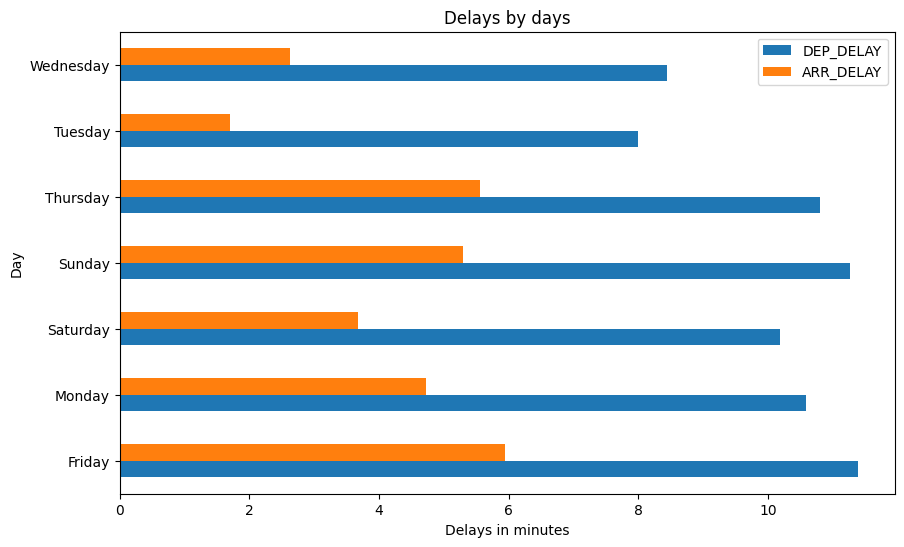

Text(0, 0.5, 'Day')

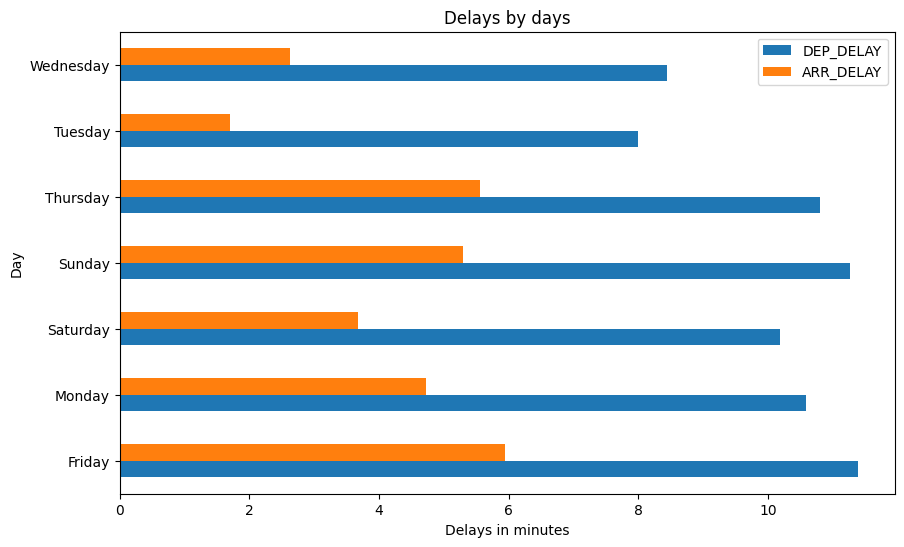

In [39]:
df['DAY'] = pd.to_datetime(df['FL_DATE'])
df['DAY_NAME']= df['DAY'].dt.day_name()

day_delay = df.groupby('DAY_NAME')[['DEP_DELAY', 'ARR_DELAY']].mean()
delays_by_day = day_delay.plot(kind='barh', figsize=(10, 6));
delays_by_day.set_title('Delays by days')
delays_by_day.set_xlabel('Delays in minutes')
delays_by_day.set_ylabel('Day')




---



**11. How do delays vary by month or season (winter, summer, etc.)?**

Flight delays exhibit clear seasonality, peaking during Summer (13.8 min dep delay) and Winter (10.2 min).
These periods align with extreme weather and heavy passenger loads, while Fall remains the most reliable travel season.

In [40]:
df['MONTH'] = df['DAY'].dt.month

months_delay = df.groupby(['MONTH'])[['DEP_DELAY', 'ARR_DELAY']].mean()

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['SEASON'] = df['MONTH'].apply(get_season)

season_delay = df.groupby('SEASON')[['DEP_DELAY', 'ARR_DELAY']].mean()
season_delay


,DEP_DELAY,ARR_DELAY
SEASON,,
Fall,6.524951,0.374389
Spring,9.075620,3.012714
Summer,13.814723,8.623259
Winter,10.181431,4.026548


,DEP_DELAY,ARR_DELAY
SEASON,,
Fall,6.524951,0.374389
Spring,9.075620,3.012714
Summer,13.814723,8.623259
Winter,10.181431,4.026548




---



**12. Are evening flights delayed more often than morning flights?**

Evening flights experience the longest average delays, departing about 16 minutes late and arriving over 10 minutes behind schedule.

Afternoon flights also show notable delays, likely due to cumulative congestion from earlier flights.

Morning flights are the most punctual, often departing within 5 minutes of schedule and sometimes even arriving early.

Night flights (post-midnight departures) tend to be lightly loaded and often arrive early due to lower air traffic.

The delay buildup over the day is a cascading effect — small morning delays propagate across flights, aircraft rotations, and crews.

Airports and airlines often schedule buffer time in the late evening, but it’s insufficient to offset the accumulated lag.

Passengers seeking on-time reliability should prefer early morning departures whenever possible.

In [41]:

def time_of_day(hour):
  if hour in range(0,6):
    return 'Night'
  elif hour in range(6,12):
    return 'Morning'
  elif hour in range(12,18):
    return 'Afternoon'
  else:
    return 'Evening'

df['TIME_OF_DAY'] = df['SCHEDULE_HOUR'].apply(time_of_day)
delay_by_time_of_day = df.groupby('TIME_OF_DAY')[['DEP_DELAY', 'ARR_DELAY']].mean()
delay_by_time_of_day

,DEP_DELAY,ARR_DELAY
TIME_OF_DAY,,
Afternoon,11.909289,6.410556
Evening,16.425539,10.273886
Morning,5.308132,-0.659764
Night,4.902731,-1.993765


,DEP_DELAY,ARR_DELAY
TIME_OF_DAY,,
Afternoon,11.909289,6.410556
Evening,16.425539,10.273886
Morning,5.308132,-0.659764
Night,4.902731,-1.993765




---



**13. What is the average delay caused by each factor:**

**Carrier, Weather, NAS (Air Traffic Control), Security, Late aircraft**

The largest contributors to total delay are:
🔹 Late aircraft arrivals (4.53 min)
🔹 Airline-related issues (4.41 min)

Together, these two factors account for over 60% of total average delay time.

Air Traffic Control (NAS) delays are moderate, around 2.3 minutes on average.

Weather-related delays are relatively low (0.7 min), but they’re highly sporadic — a few severe storms can spike this number.

Security delays are minimal (0.03 min) — rare events like extra screening or threats.

In [42]:
from collections.abc import AsyncGenerator
reason_of_delay = df[
    ['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
     'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']
].fillna(0).mean().sort_values(ascending=False)

reason_of_delay


,0
DELAY_DUE_LATE_AIRCRAFT,4.532725
DELAY_DUE_CARRIER,4.405987
DELAY_DUE_NAS,2.342720
DELAY_DUE_WEATHER,0.709194
DELAY_DUE_SECURITY,0.025969


,0
DELAY_DUE_LATE_AIRCRAFT,4.532725
DELAY_DUE_CARRIER,4.405987
DELAY_DUE_NAS,2.342720
DELAY_DUE_WEATHER,0.709194
DELAY_DUE_SECURITY,0.025969




---



**14. Which cause contributes the most total delay minutes overall?**

The largest total delay comes from Late Aircraft (≈13.6 million minutes).

Carrier-related delays are a close second at 13.2 million minutes.

Air Traffic Control (NAS) causes around 7 million minutes, roughly half of the top two causes.

Weather adds about 2 million minutes, and Security is negligible.

In [43]:
total_delay_by_cause = df[
    ['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
     'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
     'DELAY_DUE_LATE_AIRCRAFT']
].fillna(0).sum().sort_values(ascending=False)

total_delay_by_cause


,0
DELAY_DUE_LATE_AIRCRAFT,13598175.0
DELAY_DUE_CARRIER,13217960.0
DELAY_DUE_NAS,7028161.0
DELAY_DUE_WEATHER,2127583.0
DELAY_DUE_SECURITY,77907.0


,0
DELAY_DUE_LATE_AIRCRAFT,13598175.0
DELAY_DUE_CARRIER,13217960.0
DELAY_DUE_NAS,7028161.0
DELAY_DUE_WEATHER,2127583.0
DELAY_DUE_SECURITY,77907.0




---



**15. How do delay causes differ by airline (e.g., is weather more for some)?**

Delay causes vary notably among airlines, reflecting differences in operations, routes, and fleet structures. Overall, carrier-related and late aircraft delays are the most significant contributors across most airlines.

SkyWest Airlines shows the highest carrier-related delays (42.1 mins) and also experiences the largest weather-related delays (10.1 mins), suggesting operational sensitivity to weather and internal inefficiencies.

Mesa Airlines, PSA Airlines, and Frontier Airlines have the highest late aircraft delays (32+ mins), indicating cascading effects from previous flight delays and tight turnaround schedules.

ExpressJet and Spirit Air Lines show elevated NAS (Air Traffic Control) delays, which is common for airlines operating in heavily congested airports.

Delta Air Lines, JetBlue, and American Airlines face strong carrier delays (around 27–31 mins), pointing toward internal scheduling or ground operation inefficiencies.

Regional carriers such as Envoy Air and Endeavor Air exhibit higher weather delays, likely due to shorter routes and exposure to local climate variations.

Hawaiian Airlines consistently reports the lowest delay times across all causes, benefiting from isolated routes and stable weather conditions.

In summary, while weather and air traffic control play a role, most delays are within airline control, driven by carrier operations and late aircraft issues. Reducing turnaround times and improving fleet coordination could significantly improve on-time performance.

In [44]:
total_delay_by_cause_airline = df[
    ['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
     'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
     'DELAY_DUE_LATE_AIRCRAFT','AIRLINE']]
delay_airline_causes = total_delay_by_cause_airline.groupby('AIRLINE')[['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
     'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
     'DELAY_DUE_LATE_AIRCRAFT']]

delay_airline_causes_plot = delay_airline_causes.mean().round(1).sort_values('DELAY_DUE_CARRIER',ascending=False)
delay_airline_causes_plot


,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
AIRLINE,,,,,
SkyWest Airlines Inc.,42.1,10.1,7.8,0.1,21.5
JetBlue Airways,31.5,2.1,14.7,0.2,29.6
Delta Air Lines Inc.,31.4,3.8,14.1,0.1,18.7
Mesa Airlines Inc.,30.4,7.5,12.4,0.1,32.3
American Airlines Inc.,27.1,3.9,12.5,0.2,31.0
Hawaiian Airlines Inc.,25.8,1.4,1.4,0.2,17.0
ExpressJet Airlines LLC d/b/a aha!,25.8,4.1,31.4,0.0,23.8
Endeavor Air Inc.,24.6,5.2,18.2,0.0,26.8
Allegiant Air,22.9,5.4,13.6,0.2,31.0


,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
AIRLINE,,,,,
SkyWest Airlines Inc.,42.1,10.1,7.8,0.1,21.5
JetBlue Airways,31.5,2.1,14.7,0.2,29.6
Delta Air Lines Inc.,31.4,3.8,14.1,0.1,18.7
Mesa Airlines Inc.,30.4,7.5,12.4,0.1,32.3
American Airlines Inc.,27.1,3.9,12.5,0.2,31.0
Hawaiian Airlines Inc.,25.8,1.4,1.4,0.2,17.0
ExpressJet Airlines LLC d/b/a aha!,25.8,4.1,31.4,0.0,23.8
Endeavor Air Inc.,24.6,5.2,18.2,0.0,26.8
Allegiant Air,22.9,5.4,13.6,0.2,31.0




---



**16. What are the top 10 routes (ORIGIN → DEST) with the highest average delay?**

The analysis of average delays by route shows that certain connections experience extremely high delay times, often due to isolated or infrequent flights (e.g., DEN → ABE, MIA → HSV). However, after filtering out extreme outliers, consistent delay-prone routes typically involve regional airports or busy hub pairs, reflecting both congestion and operational constraints.

This route-level insight can help airlines identify problematic city pairs for schedule adjustments or resource allocation to minimize recurring delays.


In [45]:
df['ROUTE'] = df['ORIGIN'] + ' → ' + df['DEST']
route_delay = df.groupby('ROUTE')[['DEP_DELAY', 'ARR_DELAY']].mean().sort_values('DEP_DELAY', ascending=False)
route_delay.head(10)

,DEP_DELAY,ARR_DELAY
ROUTE,,
DEN → ABE,1089.000000,1080.000000
MIA → HSV,681.000000,677.000000
FCA → LGA,394.500000,404.250000
SFB → GFK,297.333333,283.166667
COS → SAN,203.000000,-10.000000
CHA → MSP,201.000000,206.000000
PSC → SAN,199.714286,204.428571
VPS → STC,195.000000,198.000000
KOA → BLI,185.000000,149.000000


,DEP_DELAY,ARR_DELAY
ROUTE,,
DEN → ABE,1089.000000,1080.000000
MIA → HSV,681.000000,677.000000
FCA → LGA,394.500000,404.250000
SFB → GFK,297.333333,283.166667
COS → SAN,203.000000,-10.000000
CHA → MSP,201.000000,206.000000
PSC → SAN,199.714286,204.428571
VPS → STC,195.000000,198.000000
KOA → BLI,185.000000,149.000000


In [46]:
df_filtered = df[(df['DEP_DELAY'] < 300) & (df['ARR_DELAY'] < 300)]
route_delay = (
    df_filtered.groupby('ROUTE')[['DEP_DELAY', 'ARR_DELAY']]
    .mean()
    .sort_values('DEP_DELAY', ascending=False)
)
route_delay.head(10)


,DEP_DELAY,ARR_DELAY
ROUTE,,
CHA → MSP,201.00,206.0
VPS → STC,195.00,198.0
KOA → BLI,185.00,149.0
GRB → FLL,163.00,160.0
MSY → GSP,128.00,120.0
TWF → SFO,123.75,103.5
SBN → SFO,109.00,88.0
PSM → SAV,104.00,100.0
STL → SAV,100.00,94.0


,DEP_DELAY,ARR_DELAY
ROUTE,,
CHA → MSP,201.00,206.0
VPS → STC,195.00,198.0
KOA → BLI,185.00,149.0
GRB → FLL,163.00,160.0
MSY → GSP,128.00,120.0
TWF → SFO,123.75,103.5
SBN → SFO,109.00,88.0
PSM → SAV,104.00,100.0
STL → SAV,100.00,94.0




---



**17. How does average delay change with flight distance?**

Overall, flight delays increase with distance up to ~2000 miles, after which they stabilize or slightly improve.
This pattern suggests that operational complexity and airport congestion play a greater role in delays than flight duration alone.

/tmp/ipykernel_1737/536658769.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_delay = df.groupby('DISTANCE_BIN')[['DEP_DELAY', 'ARR_DELAY']].mean().round(2)


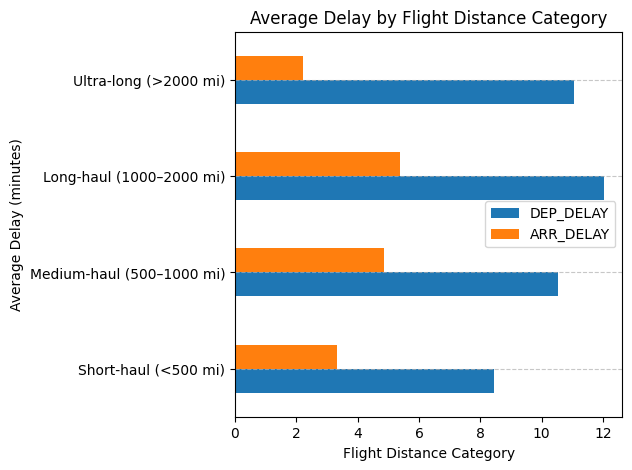

/tmp/ipykernel_1737/536658769.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_delay = df.groupby('DISTANCE_BIN')[['DEP_DELAY', 'ARR_DELAY']].mean().round(2)


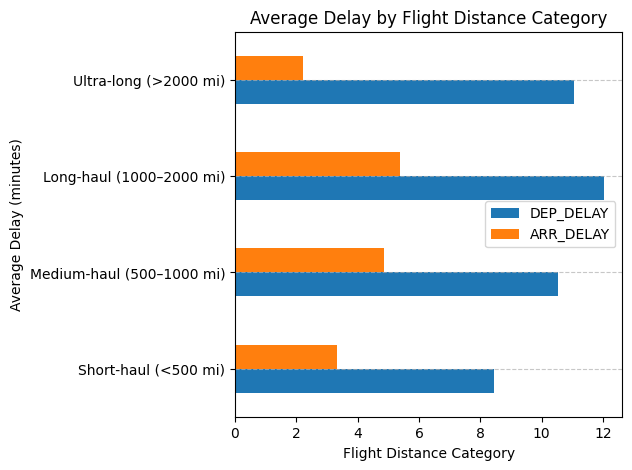

In [47]:
df['DISTANCE'].describe()
bins = [0, 500, 1000, 2000, 6000]
labels = ['Short-haul (<500 mi)', 'Medium-haul (500–1000 mi)', 'Long-haul (1000–2000 mi)', 'Ultra-long (>2000 mi)']

df['DISTANCE_BIN'] = pd.cut(df['DISTANCE'], bins=bins, labels=labels, include_lowest=True)
distance_delay = df.groupby('DISTANCE_BIN')[['DEP_DELAY', 'ARR_DELAY']].mean().round(2)
distance_delay

distance_delay.plot(kind='barh', figsize=(5,5))
plt.title('Average Delay by Flight Distance Category')
plt.xlabel('Flight Distance Category')
plt.ylabel('Average Delay (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show();




---



**18. Which routes have the highest cancellation rates?**

The New York (LGA) ↔ Chicago (ORD) corridor had the highest number of cancellations, likely due to:

- Heavy air traffic between two major hubs.

- Frequent weather disruptions.

- Tight scheduling at both airports.

Other high-cancellation routes include Houston ↔ Dallas and Boston ↔ LaGuardia, also busy domestic corridors with high flight volumes.

These results represent raw counts, so routes with more total flights will naturally appear higher.

In [48]:
cancel_by_route = (
    df.groupby('ROUTE')['CANCELLED']
      .sum()
      .sort_values(ascending=False)
)
cancel_by_route.head(10)



,CANCELLED
ROUTE,
LGA → ORD,219.0
ORD → LGA,202.0
HOU → DAL,172.0
BOS → LGA,164.0
DCA → BOS,142.0
SFO → LAX,139.0
LGA → BOS,137.0
DAL → HOU,136.0
LAX → SFO,134.0


,CANCELLED
ROUTE,
LGA → ORD,219.0
ORD → LGA,202.0
HOU → DAL,172.0
BOS → LGA,164.0
DCA → BOS,142.0
SFO → LAX,139.0
LGA → BOS,137.0
DAL → HOU,136.0
LAX → SFO,134.0




---



---



##Summary and Conclusion

- The dataset covers ~3M U.S. flights, with Southwest, Delta, and American Airlines operating the most.

- About 2.6% of flights were cancelled and 17% delayed; morning flights are most punctual while evening flights face the longest delays.

- Average delays: ~10 min departure and ~4 min arrival.

- Late aircraft and carrier issues are the top delay causes; weather and security contribute least.

- Summer shows the worst seasonal delays, while fall performs best.

- Routes like LGA ↔ ORD and HOU ↔ DAL see the most cancellations.

- Short-haul flights tend to be more delay-prone than longer ones.

**Conclusion:**
Delays are mainly driven by schedule congestion and late aircraft turnover, not weather.
Improving aircraft turnaround, scheduling buffers, and coordination between airports and airlines can significantly enhance on-time performance.
